<a href="https://colab.research.google.com/github/Juanma-dev-tech/aprendizaje-automatico-1/blob/main/TP4/TP4_AA1_regresion_lineal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP4 AA1

**Juan Manuel Yñiguez**

## Indicaciones básicas

0) Debe usar este notebook como template para su entrega. Haga una copia y comience a completar las consignas.

1) Cada uno debe completar las consignas indicadas en este notebook.

2)
3) No pueden repetir el mismo dataset que ya haya definido un compañero.

4) copias explícitas de secciones enteras del trabajo de otro será penalizado disminuyendo su puntuación.

5) No se olvide de añadir las fuentes de inspiración de su código (blogs, prompts de chatgpt o similar).

6) Además de todo el código que agregue, es importante que sepa interpretarlo. Agregue texto explicativo en cada sección. Esto le ayudará al momento del coloquio / parcial

7) Revise las fecha límite de entrega de este trabajo

# ENTREGA

* En el foro destinado a la tarea debe postear al menos tres veces:
  - La primera vez para indicar el dataset elegido
  - Una segunda vez para postear su entrega
  - Una tercera vez para brindar feedback a alguien más en el foro.
  - Puede comentar más de un posteo de sus compañeros siempre y cuando el intercambio sea respetuoso y fructífero.
* Deben postear como solución un enlace a su notebook colab público y también un enlace al mismo notebook alojado en su repositorio GitHub.
* Debe sumar el enlace a un video donde muestre su solución y explique lo realizado. Duración máxima: 5 - 10 minutos. Puede grabarse a Ud. mismo usando una sesión de zoom y grabar localmente. Puede subir el video a su youtube personal como privado o Unlisted.
* Enlaces no accesibles o enlaces erróneos es igual a determinar que la tarea no ha sido entregada. Corrobore la viabilidad de los enlaces que postea.


#**Tarea: Aplicación de Regresión Lineal y Análisis de Importancia de Variables**  
**Objetivo**: Aplicar un modelo de regresión lineal a un dataset de su elección, evaluar su rendimiento e identificar las variables más relevantes para la predicción.

---

# **Instrucciones**:

#1. **Selección del Dataset**  
   - Elijan un dataset de UCI ML Repository del siguiente enlace: https://archive.ics.uci.edu/datasets/?Task=Regression&skip=0&take=10&sort=desc&orderBy=NumHits&search=  
   - Requisitos:  
     - Debe tener al menos 4 variables numéricas continuas (1 target, 3 o más features).  
     - Idealmente, que las features tengan distintas escalas o unidades ( no excluyente).
     - Revisar en el foro de la tarea que dicho dataset no haya sido ya elegido por otra persona.
     - Postee en el foro de la tarea el dataset que eligió. Continue al siguiente punto.  



## Resolución:

In [16]:
import pandas as pd
import requests
import zipfile
from io import BytesIO

url = "https://archive.ics.uci.edu/static/public/243/yacht+hydrodynamics.zip"

response = requests.get(url)

with zipfile.ZipFile(BytesIO(response.content)) as z:
    with z.open("yacht_hydrodynamics.data") as f:
        df = pd.read_csv(f, sep=r"\s+", header=None)

df.columns = [
    "Centro_Flotacion",
    "Coef_Prismatico",
    "Eslora_Desplazamiento",
    "Manga_Calado",
    "Eslora_Manga",
    "Numero_Froude",
    "Resistencia_Residual"
]

df.head()

,Centro_Flotacion,Coef_Prismatico,Eslora_Desplazamiento,Manga_Calado,Eslora_Manga,Numero_Froude,Resistencia_Residual
0,-2.3,0.568,4.78,3.99,3.17,0.125,0.11
1,-2.3,0.568,4.78,3.99,3.17,0.150,0.27
2,-2.3,0.568,4.78,3.99,3.17,0.175,0.47
3,-2.3,0.568,4.78,3.99,3.17,0.200,0.78
4,-2.3,0.568,4.78,3.99,3.17,0.225,1.18


### Descripción de las variables

El dataset Yacht Hydrodynamics contiene mediciones relacionadas con la geometría de embarcaciones a vela y parámetros de navegación.

Las variables utilizadas son:

- Centro_Flotacion: posición longitudinal del centro de flotación.
- Coef_Prismatico: coeficiente prismático del casco.
- Eslora_Desplazamiento: relación entre la eslora y el desplazamiento.
- Manga_Calado: relación entre la manga y el calado.
- Eslora_Manga: relación entre la eslora y la manga.
- Numero_Froude: número adimensional que relaciona la velocidad con la longitud característica de la embarcación.
- Resistencia_Residual: resistencia hidrodinámica residual por unidad de peso de desplazamiento (variable objetivo).


## 2. **Análisis exploratorio (previo al modelado)**  
   - Describan las variables (media, distribución, outliers).  
   - Visualizen:  
     - Histogramas o boxplots para ver distribuciones.  
     - Gráficos de dispersión (scatterplots) entre features y target.  
   - **Pregunta clave**: ¿Qué relaciones lineales preliminares observan?  


## Resolución:

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308 entries, 0 to 307
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Centro_Flotacion       308 non-null    float64
 1   Coef_Prismatico        308 non-null    float64
 2   Eslora_Desplazamiento  308 non-null    float64
 3   Manga_Calado           308 non-null    float64
 4   Eslora_Manga           308 non-null    float64
 5   Numero_Froude          308 non-null    float64
 6   Resistencia_Residual   308 non-null    float64
dtypes: float64(7)
memory usage: 17.0 KB


### Estructura del dataset

A partir de la inspección inicial del dataset se observa que contiene 308 registros y 7 variables numéricas continuas. Todas las columnas fueron interpretadas correctamente como valores de tipo `float64`, por lo que no fue necesario realizar conversiones de tipo de dato antes de continuar con el análisis.


In [18]:
df.describe()

,Centro_Flotacion,Coef_Prismatico,Eslora_Desplazamiento,Manga_Calado,Eslora_Manga,Numero_Froude,Resistencia_Residual
count,308.000000,308.000000,308.000000,308.000000,308.000000,308.000000,308.000000
mean,-2.381818,0.564136,4.788636,3.936818,3.206818,0.287500,10.495357
std,1.513219,0.023290,0.253057,0.548193,0.247998,0.100942,15.160490
min,-5.000000,0.530000,4.340000,2.810000,2.730000,0.125000,0.010000
25%,-2.400000,0.546000,4.770000,3.750000,3.150000,0.200000,0.777500
50%,-2.300000,0.565000,4.780000,3.955000,3.150000,0.287500,3.065000
75%,-2.300000,0.574000,5.100000,4.170000,3.510000,0.375000,12.815000
max,0.000000,0.600000,5.140000,5.350000,3.640000,0.450000,62.420000


### Estadísticas descriptivas

Las estadísticas descriptivas permiten conocer los valores promedio, la dispersión y los rangos de cada variable. Se observa que las variables presentan escalas diferentes. Por ejemplo, el coeficiente prismático toma valores cercanos a 0.5, mientras que la resistencia residual alcanza valores superiores a 60.

Estas diferencias de escala serán tenidas en cuenta durante la etapa de preprocesamiento mediante la aplicación de una técnica de normalización.


In [19]:
df.isnull().sum()

,0
Centro_Flotacion,0
Coef_Prismatico,0
Eslora_Desplazamiento,0
Manga_Calado,0
Eslora_Manga,0
Numero_Froude,0
Resistencia_Residual,0


### Valores faltantes

No se detectaron valores faltantes en ninguna de las variables del dataset. Por este motivo, no fue necesario aplicar técnicas de imputación ni eliminar registros antes de continuar con el análisis.


### Distribución de las variables

Como parte del análisis exploratorio se estudió la distribución de cada variable mediante histogramas. Esto permite observar cómo se distribuyen los valores, identificar posibles asimetrías y detectar comportamientos inusuales en los datos.

Además, resulta útil para comprender las características generales del dataset antes de aplicar cualquier técnica de preprocesamiento o modelado.


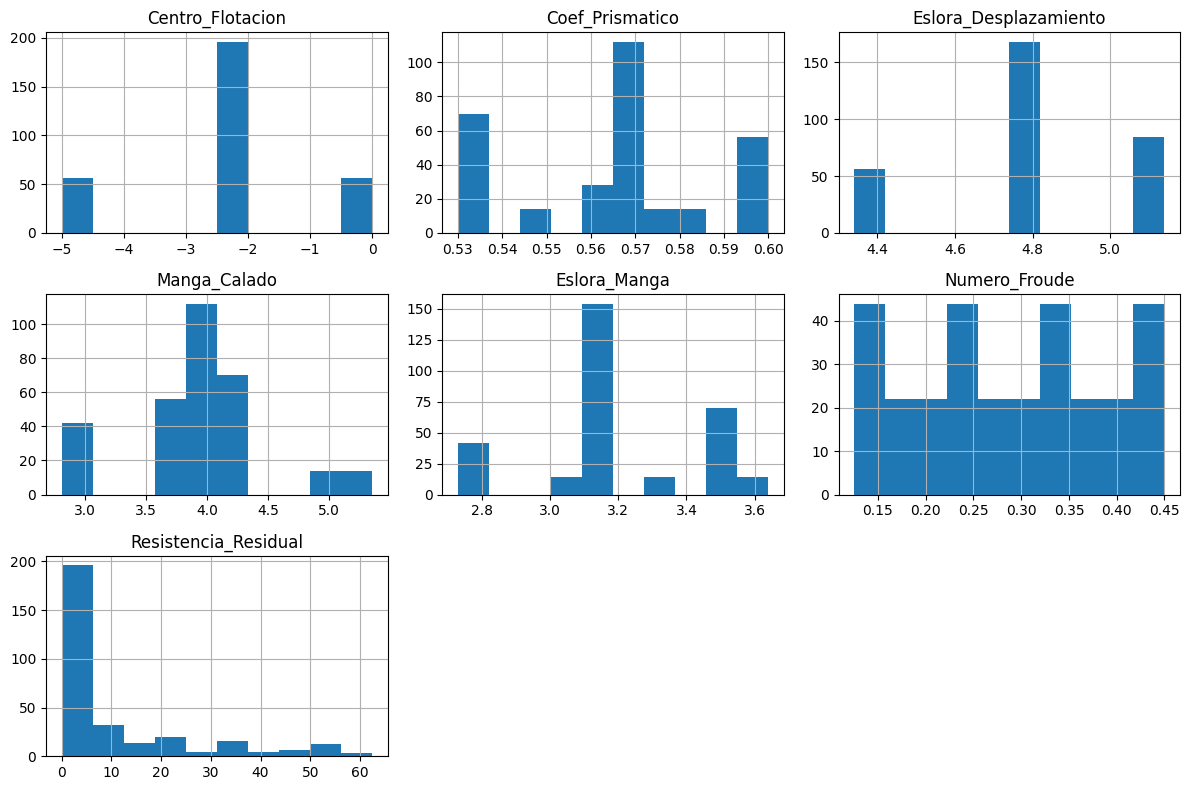

In [20]:
import matplotlib.pyplot as plt

df.hist(figsize=(12,8))
plt.tight_layout()
plt.show()

### Observaciones sobre la distribución de las variables

A partir de los histogramas se observa que varias variables presentan valores concentrados en determinados rangos, lo que indica que algunas configuraciones de los yates aparecen con mayor frecuencia dentro del dataset.

También se aprecia que las variables no comparten la misma escala de valores. Mientras que algunas toman valores cercanos a 0 o 1, la variable objetivo `Resistencia_Residual` alcanza valores considerablemente mayores.

Por otro lado, la mayor parte de las observaciones de la variable objetivo se concentra en valores bajos, aunque existen algunos casos con resistencias significativamente más elevadas. Este comportamiento sugiere una distribución asimétrica que será analizada con mayor detalle mediante los diagramas de caja.


### Análisis de dispersión y valores atípicos

Luego de observar la distribución de las variables mediante histogramas, se utilizan diagramas de caja (boxplots) para complementar el análisis exploratorio.

Estos gráficos permiten visualizar la dispersión de los datos, comparar los rangos de cada variable e identificar posibles valores atípicos. Además, ayudan a determinar si será necesario aplicar algún tratamiento específico antes de entrenar el modelo.

Dado que la variable objetivo mostró una distribución concentrada en valores bajos y algunos valores considerablemente más elevados, resulta especialmente interesante verificar si existen observaciones que se apartan del comportamiento general del conjunto de datos.



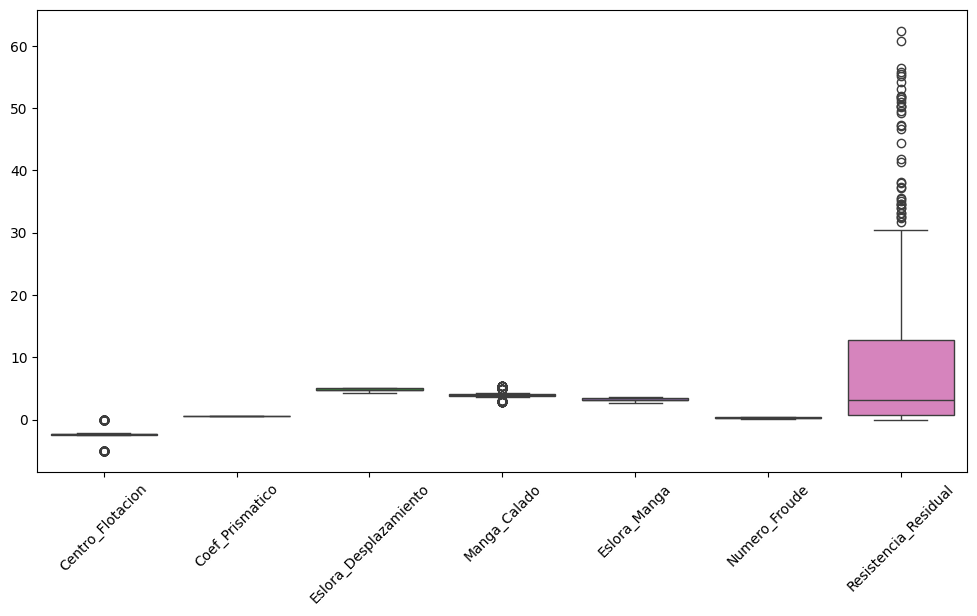

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.show()

### Observaciones sobre los boxplots

Los diagramas de caja permiten observar la dispersión de las variables y detectar posibles valores atípicos.

Se aprecia que la variable objetivo `Resistencia_Residual` presenta una dispersión considerablemente mayor que el resto de las variables y una cantidad importante de observaciones por encima del rango principal de datos. Esto coincide con lo observado en los histogramas, donde la mayoría de los registros se concentraban en valores bajos y existían algunos casos con resistencias significativamente más elevadas.

También se observan algunos posibles valores atípicos en variables como `Centro_Flotacion` y `Manga_Calado`, aunque en menor medida.

Dado que el dataset representa mediciones obtenidas en experimentos hidrodinámicos reales, en esta etapa no se eliminarán dichos valores. Primero se evaluará el comportamiento del modelo utilizando la totalidad de los registros disponibles.


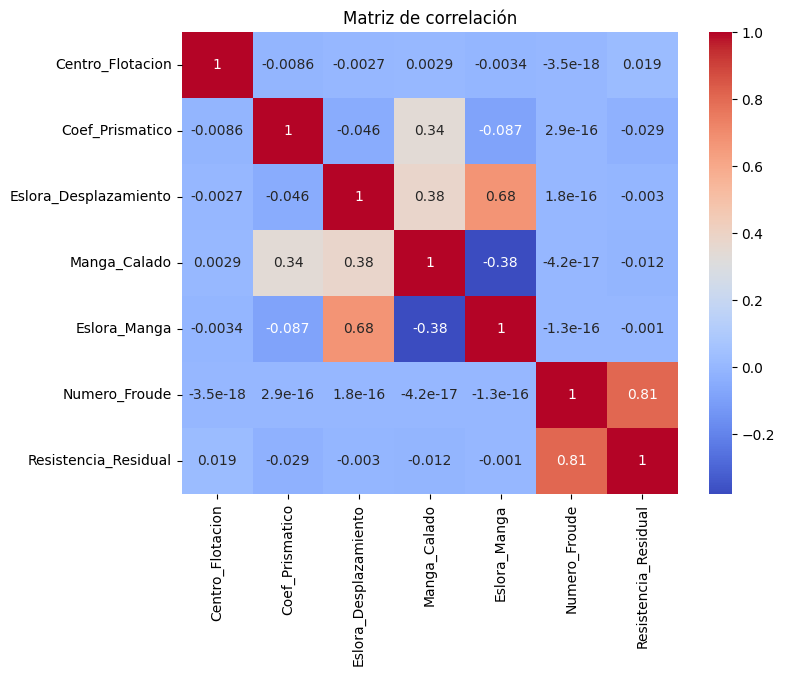

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()

### Observaciones sobre la matriz de correlación

La matriz de correlación muestra que la variable `Numero_Froude` presenta una correlación positiva fuerte con la variable objetivo `Resistencia_Residual` (0.81), destacándose claramente sobre el resto de las variables.

Por el contrario, las demás variables exhiben correlaciones muy bajas con la resistencia residual, lo que sugiere una relación lineal débil o inexistente con el objetivo de predicción.

A partir de este análisis preliminar puede anticiparse que `Numero_Froude` tendrá un papel importante dentro del modelo de regresión lineal, ya que es la variable que muestra la asociación más fuerte con la variable objetivo.


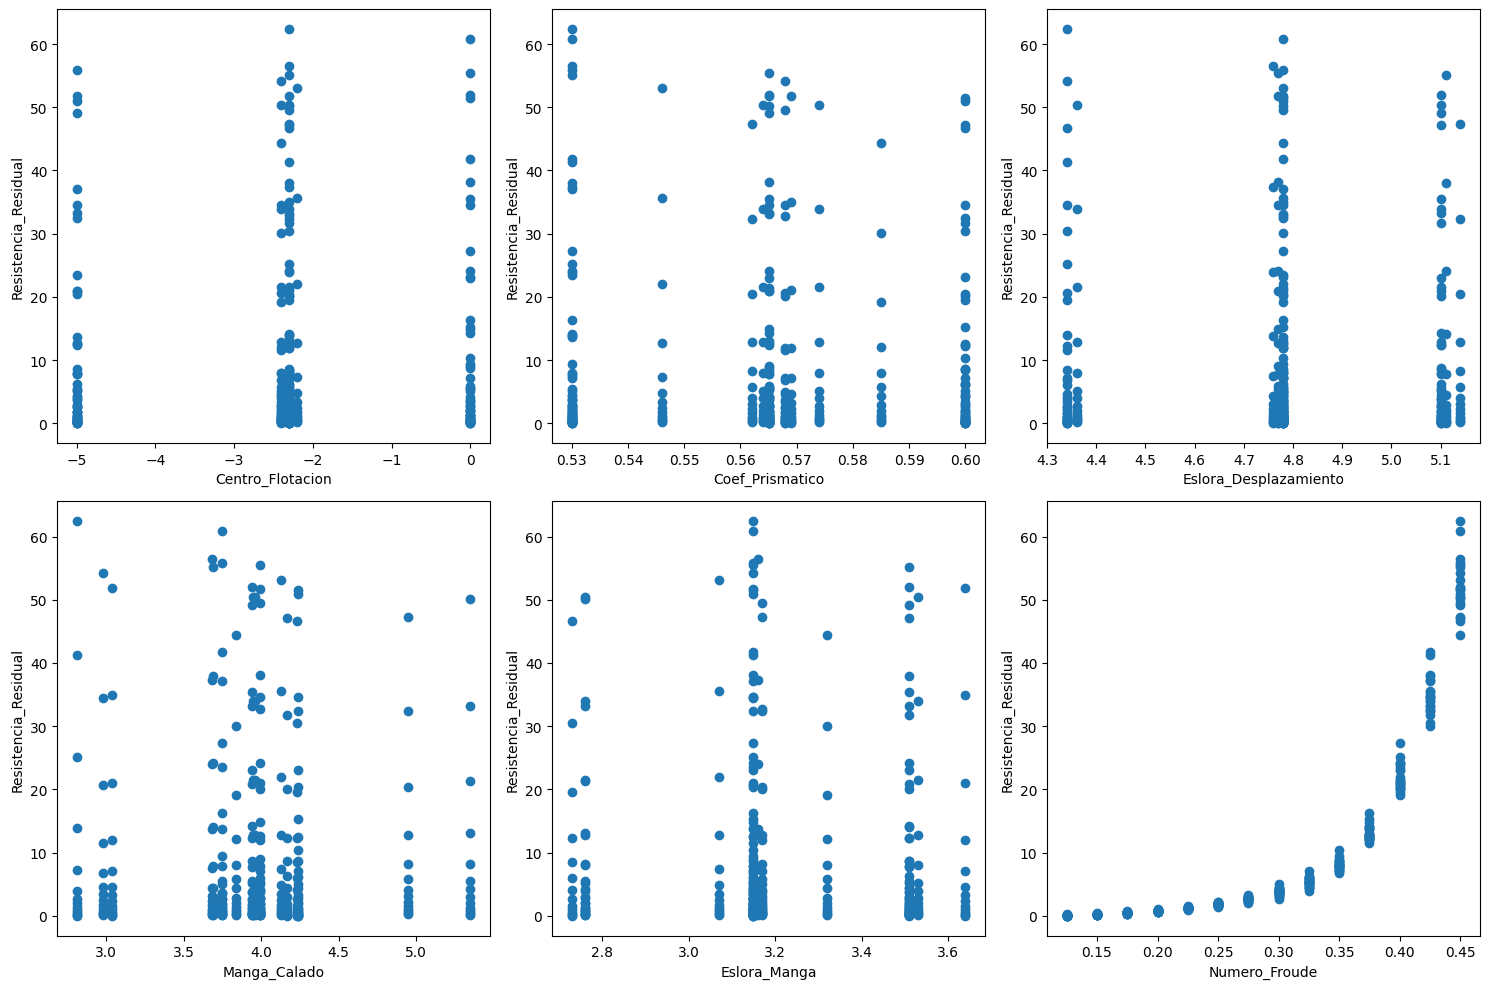

In [23]:
features = df.columns[:-1]
target = "Resistencia_Residual"

fig, axes = plt.subplots(2, 3, figsize=(15,10))

for ax, feature in zip(axes.flatten(), features):
    ax.scatter(df[feature], df[target])
    ax.set_xlabel(feature)
    ax.set_ylabel(target)

plt.tight_layout()
plt.show()

### Observaciones finales del análisis exploratorio

Los gráficos de dispersión muestran que la mayoría de las variables presentan una relación débil con la variable objetivo `Resistencia_Residual`. En general, los puntos aparecen dispersos y no se observa una tendencia lineal claramente definida.

La excepción es `Numero_Froude`, donde se aprecia una relación positiva muy marcada con la resistencia residual. A medida que aumenta el valor de esta variable, la resistencia residual también tiende a incrementarse de forma significativa.

Esta observación coincide con los resultados obtenidos en la matriz de correlación, donde `Numero_Froude` presentó la asociación más fuerte con la variable objetivo. Por lo tanto, antes incluso de entrenar el modelo, existían indicios de que esta variable tendría una influencia importante en la capacidad predictiva de la regresión lineal.


## 3. **Preprocesamiento**  
   - Limpieza: Manejen missing values (eliminar, imputar) y outliers (si es necesario).  
   - Limpieza: indique cuáles features descarta. Justifique.
   - Indique si usará o no variables categóricas. Justifique. Realice su preprocesamiento adeucado.
   - Escalen las features (p.ej., StandardScaler) para comparar coeficientes después.  
   - Dividan en train/test (70-30 o 80-20).  

## Resolución:

## Preprocesamiento de los datos

Antes de entrenar el modelo se realiza una etapa de preprocesamiento para preparar los datos.

Durante el análisis exploratorio se verificó que el dataset no presenta valores faltantes. Asimismo, aunque se identificaron algunos posibles valores atípicos, se decidió conservarlos debido a que corresponden a mediciones reales obtenidas en experimentos hidrodinámicos.

Todas las variables disponibles son numéricas continuas, por lo que no es necesario aplicar técnicas de codificación para variables categóricas.

Además, se observó que las variables presentan diferentes escalas y rangos de valores. Por este motivo se utilizará StandardScaler para estandarizarlas antes del entrenamiento del modelo de regresión lineal.

Finalmente, los datos se dividirán en conjuntos de entrenamiento y prueba utilizando una proporción 80-20.

### Decisiones de preprocesamiento

-No se eliminaron registros del dataset.

-No fue necesario imputar valores faltantes.

-No se descartó ninguna variable, ya que todas representan características relevantes para el fenómeno físico estudiado.

-No se utilizaron variables categóricas porque el dataset está compuesto únicamente por variables numéricas continuas.

-Se aplicará estandarización mediante StandardScaler para llevar todas las variables a una escala comparable.

-Se utilizará una división 80% entrenamiento y 20% prueba para evaluar la capacidad de generalización del modelo.


### Estandarización de las variables

Las variables del dataset presentan diferentes escalas y rangos de valores. Para evitar que aquellas con valores numéricamente más grandes tengan una influencia desproporcionada durante el entrenamiento, se aplicará una estandarización mediante StandardScaler.

Esta técnica transforma cada variable para que tenga media cercana a 0 y desviación estándar cercana a 1, permitiendo trabajar con todas las variables en una escala comparable.

In [24]:
from sklearn.preprocessing import StandardScaler

X = df.drop("Resistencia_Residual", axis=1)
y = df["Resistencia_Residual"]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled.head()

,Centro_Flotacion,Coef_Prismatico,Eslora_Desplazamiento,Manga_Calado,Eslora_Manga,Numero_Froude
0,0.054157,0.166162,-0.034184,0.097171,-0.148703,-1.612452
1,0.054157,0.166162,-0.034184,0.097171,-0.148703,-1.364382
2,0.054157,0.166162,-0.034184,0.097171,-0.148703,-1.116313
3,0.054157,0.166162,-0.034184,0.097171,-0.148703,-0.868243
4,0.054157,0.166162,-0.034184,0.097171,-0.148703,-0.620174


### Observaciones sobre la estandarización

Se observa que, luego de aplicar StandardScaler, las variables dejaron de expresarse en sus unidades originales y pasaron a una escala común. Los valores ahora se encuentran centrados alrededor de cero y expresados en términos de desviaciones estándar respecto de la media.

Esta transformación resulta útil porque permite comparar variables que originalmente tenían rangos diferentes y facilita la interpretación posterior de los coeficientes del modelo de regresión lineal.


### División de los datos en entrenamiento y prueba

Para evaluar la capacidad de generalización del modelo, los datos se dividirán en dos conjuntos.

El conjunto de entrenamiento será utilizado para ajustar el modelo de regresión lineal, mientras que el conjunto de prueba permitirá evaluar su rendimiento sobre observaciones que no fueron utilizadas durante el entrenamiento.

Se utilizará una proporción de 80% para entrenamiento y 20% para prueba.


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (246, 6)
X_test : (62, 6)
y_train: (246,)
y_test : (62,)


### Observaciones sobre la división de datos

Luego de la partición, el conjunto de entrenamiento quedó compuesto por 246 observaciones, mientras que el conjunto de prueba contiene 62 observaciones.

Esta división permitirá entrenar el modelo utilizando la mayor parte de los datos disponibles y, al mismo tiempo, evaluar su capacidad de generalización sobre datos no utilizados durante el entrenamiento.





## 4. **Regresión Lineal**  
   - Ajusten un modelo de regresión lineal (usando `sklearn.linear_model.LinearRegression`).  
   - Obtengan:  
     - Coeficientes (pesos) del modelo.  
     - Evaluar métricas en el set de entrenamiento y en el de testeo: **R²**, MSE (error cuadrático medio), MAE.  


## Entrenamiento del modelo de regresión lineal

Una vez finalizado el preprocesamiento de los datos, se procede a entrenar un modelo de regresión lineal utilizando las variables predictoras disponibles.

El objetivo es estimar la variable `Resistencia_Residual` a partir de las características geométricas de la embarcación y del número de Froude.

Posteriormente se evaluará el desempeño del modelo tanto sobre el conjunto de entrenamiento como sobre el conjunto de prueba mediante distintas métricas de regresión.


In [26]:
from sklearn.linear_model import LinearRegression

modelo = LinearRegression()

modelo.fit(X_train, y_train)

LinearRegression()

In [27]:
coeficientes = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": modelo.coef_
})

coeficientes

,Variable,Coeficiente
0,Centro_Flotacion,0.597093
1,Coef_Prismatico,-0.246913
2,Eslora_Desplazamiento,-0.047135
3,Manga_Calado,-0.101274
4,Eslora_Manga,-0.071115
5,Numero_Froude,12.746088


### Evaluación del modelo

Una vez entrenado el modelo, se generan predicciones tanto sobre el conjunto de entrenamiento como sobre el conjunto de prueba.

Para evaluar el desempeño se utilizarán tres métricas:

* R²: indica qué proporción de la variabilidad de la variable objetivo es explicada por el modelo.
* MSE (Mean Squared Error): mide el error cuadrático medio de las predicciones.
* MAE (Mean Absolute Error): mide el error absoluto promedio entre los valores reales y los predichos.

La comparación entre entrenamiento y prueba permitirá analizar la capacidad de generalización del modelo.


In [28]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Predicciones
y_train_pred = modelo.predict(X_train)
y_test_pred = modelo.predict(X_test)

# Métricas entrenamiento
r2_train = r2_score(y_train, y_train_pred)
mse_train = mean_squared_error(y_train, y_train_pred)
mae_train = mean_absolute_error(y_train, y_train_pred)

# Métricas prueba
r2_test = r2_score(y_test, y_test_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)

print("=== Entrenamiento ===")
print(f"R² : {r2_train:.4f}")
print(f"MSE: {mse_train:.4f}")
print(f"MAE: {mae_train:.4f}")

print("\n=== Prueba ===")
print(f"R² : {r2_test:.4f}")
print(f"MSE: {mse_test:.4f}")
print(f"MAE: {mae_test:.4f}")

=== Entrenamiento ===
R² : 0.6675
MSE: 81.6661
MAE: 7.4203

=== Prueba ===
R² : 0.5450
MSE: 67.6026
MAE: 6.8075


### Análisis de las métricas obtenidas

El modelo obtuvo un coeficiente de determinación (R²) de 0.6675 sobre el conjunto de entrenamiento y de 0.5450 sobre el conjunto de prueba. Esto indica que el modelo logra explicar una parte importante de la variabilidad de la resistencia residual, aunque todavía existe margen de mejora.

La diferencia entre ambos valores de R² no es excesiva, por lo que no se observan evidencias claras de sobreajuste. Esto sugiere que el modelo mantiene una capacidad razonable de generalización sobre datos no utilizados durante el entrenamiento.

Respecto a los errores, el MAE se mantiene cercano a 7 unidades tanto en entrenamiento como en prueba, mientras que el MSE presenta valores similares en ambos conjuntos. En conjunto, estos resultados indican que el modelo captura parte del comportamiento del fenómeno estudiado, aunque existen factores o relaciones que no están siendo completamente representados por una regresión lineal simple.



## 5. **Importancia de Variables**  
   - Analicen los **coeficientes** del modelo:  
     - Valores absolutos altos → mayor impacto en el target.  
     - Signo: Relación positiva/negativa con el target.  
   - Comparen la magnitud de los coeficientes **escalados** (si usaron features en distintas unidades).  
   - **5.1. Opcional**:
     Otra forma es "desordenar" un feature y ver cómo empeora el modelo. Si al desordenarlo el error aumenta mucho, ese feature era importante. Usen métodos como:  
     - **Permutation Importance** (de sklearn) para validar importancia. Más info en https://scikit-learn.org/stable/modules/permutation_importance.html



## Resolución:

## Importancia de las variables

Una de las ventajas de la regresión lineal es que permite interpretar la contribución de cada variable a la predicción realizada por el modelo.

Dado que las variables fueron previamente estandarizadas mediante StandardScaler, los coeficientes obtenidos pueden compararse directamente entre sí. Esto permite analizar qué variables tienen una mayor influencia sobre la resistencia residual y determinar si su relación con la variable objetivo es positiva o negativa.

En esta sección se estudiará la magnitud y el signo de los coeficientes para identificar las variables más relevantes dentro del modelo.


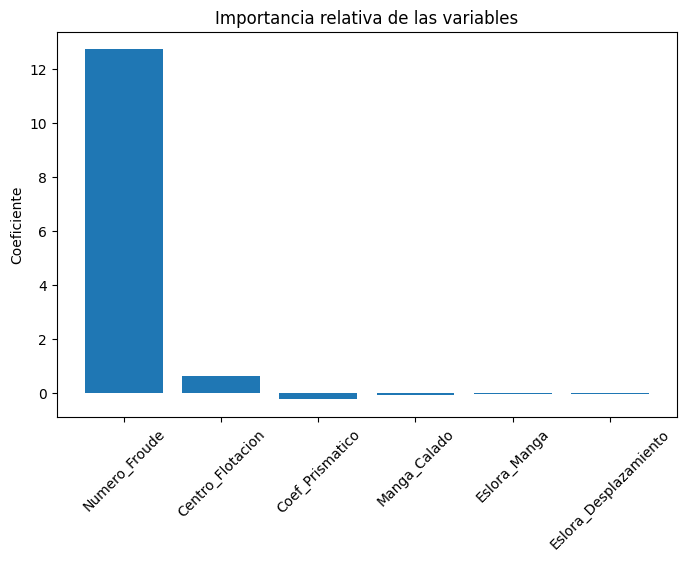

In [29]:
import matplotlib.pyplot as plt

coeficientes_ordenados = coeficientes.sort_values(
    by="Coeficiente",
    key=abs,
    ascending=False
)

plt.figure(figsize=(8,5))
plt.bar(coeficientes_ordenados["Variable"],
        coeficientes_ordenados["Coeficiente"])
plt.xticks(rotation=45)
plt.ylabel("Coeficiente")
plt.title("Importancia relativa de las variables")
plt.show()

### Interpretación de los coeficientes

Al analizar la magnitud de los coeficientes obtenidos por el modelo se observa que `Numero_Froude` presenta el valor absoluto más alto, lo que indica que es la variable con mayor impacto sobre la predicción de la resistencia residual.

En segundo lugar aparece `Centro_Flotacion`, aunque con una influencia considerablemente menor. El resto de las variables presentan coeficientes de baja magnitud, lo que sugiere una contribución limitada dentro del modelo.

Respecto al signo de los coeficientes, los valores positivos indican que un aumento de la variable tiende a incrementar la resistencia residual estimada por el modelo, mientras que los coeficientes negativos indican una relación inversa.

Dado que todas las variables fueron previamente estandarizadas mediante StandardScaler, la comparación entre coeficientes resulta válida y permite evaluar directamente su importancia relativa.


### Relación con el análisis exploratorio

Los resultados obtenidos coinciden con las observaciones realizadas durante el análisis exploratorio.

Tanto la matriz de correlación como los gráficos de dispersión mostraban que `Numero_Froude` era la variable con la relación más fuerte respecto de `Resistencia_Residual`. Posteriormente, el modelo confirmó esta observación al asignarle el coeficiente de mayor magnitud.

Por el contrario, las demás variables presentaban correlaciones bajas y gráficos de dispersión sin tendencias lineales claras, situación que también se refleja en los coeficientes relativamente pequeños obtenidos por la regresión lineal.



## 6. **Reflexión**  
   - ¿Cuáles variables son más importantes según el modelo? ¿Coincide con su análisis exploratorio?  
   - ¿El modelo tiene buen rendimiento (R² alto, MSE bajo)? Si no, ¿a qué podría deberse?  



## Resolución:

## Reflexión

De acuerdo con los coeficientes obtenidos por el modelo, la variable más importante para la predicción de la resistencia residual es `Numero_Froude`, ya que presenta el coeficiente de mayor magnitud. En segundo lugar aparece `Centro_Flotacion`, aunque con una influencia considerablemente menor. El resto de las variables muestran una contribución reducida dentro del modelo.

Estos resultados coinciden con el análisis exploratorio realizado previamente. Tanto la matriz de correlación como los gráficos de dispersión mostraban que `Numero_Froude` era la variable con la relación más fuerte respecto de `Resistencia_Residual`, observación que posteriormente fue confirmada por el modelo de regresión lineal.

Respecto al rendimiento, el modelo obtuvo un R² de 0.6675 sobre el conjunto de entrenamiento y de 0.5450 sobre el conjunto de prueba. Esto indica que logra explicar una parte importante de la variabilidad de la resistencia residual, aunque todavía existe margen de mejora. La diferencia entre ambos valores no es excesiva, por lo que no se observan evidencias claras de sobreajuste.

El hecho de que el modelo no alcance valores más altos de R² podría deberse a que algunas relaciones presentes en los datos no son completamente lineales o a la existencia de factores que no están representados por las variables disponibles en el dataset. Aun así, los resultados obtenidos permiten concluir que la regresión lineal logra capturar una parte significativa del comportamiento del fenómeno estudiado.



## **Bonus**:  
- Prueben eliminar variables "poco importantes" y reentrenar el modelo. ¿Mejora el rendimiento?  

## Bonus: Eliminación de variables poco importantes

A partir del análisis de los coeficientes se observó que `Numero_Froude` concentra gran parte de la capacidad predictiva del modelo, mientras que varias variables presentan coeficientes de magnitud reducida.

Como experimento adicional, se entrenará un nuevo modelo utilizando únicamente las variables con mayor influencia para evaluar si es posible mantener o mejorar el rendimiento reduciendo la cantidad de variables utilizadas.


In [30]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Variables seleccionadas
X_reducido = df[["Numero_Froude", "Centro_Flotacion"]]
y = df["Resistencia_Residual"]

# Escalado
scaler = StandardScaler()
X_reducido_scaled = scaler.fit_transform(X_reducido)

# División
X_train_red, X_test_red, y_train_red, y_test_red = train_test_split(
    X_reducido_scaled,
    y,
    test_size=0.2,
    random_state=42
)

# Entrenamiento
modelo_red = LinearRegression()
modelo_red.fit(X_train_red, y_train_red)

# Predicciones
y_pred_red = modelo_red.predict(X_test_red)

# Métricas
r2_red = r2_score(y_test_red, y_pred_red)
mse_red = mean_squared_error(y_test_red, y_pred_red)
mae_red = mean_absolute_error(y_test_red, y_pred_red)

print(f"R² : {r2_red:.4f}")
print(f"MSE: {mse_red:.4f}")
print(f"MAE: {mae_red:.4f}")

R² : 0.5421
MSE: 68.0357
MAE: 6.8712


### Resultados del modelo reducido

Luego de entrenar un nuevo modelo utilizando únicamente `Numero_Froude` y `Centro_Flotacion`, se observa que las métricas obtenidas son muy similares a las del modelo original.

El coeficiente de determinación (R²) disminuyó levemente de 0.5450 a 0.5421, mientras que los errores MSE y MAE se mantuvieron prácticamente sin cambios.

Estos resultados sugieren que la mayor parte de la capacidad predictiva del modelo se encuentra concentrada en las variables `Numero_Froude` y `Centro_Flotacion`. Las variables restantes aportan información adicional limitada dentro de este problema de regresión.

Por lo tanto, la eliminación de las variables menos influyentes permitió simplificar el modelo sin afectar significativamente su rendimiento.



---

### **Tips**:  
- Si el R² es muy bajo, revisen si hay relaciones no lineales (y consideren transformar features).  
- Documenten cada paso: ¡la trazabilidad es clave en ciencia de datos!  
- Al final de su trabajo debe crear un apartado de REFERENCIAS para citar todo recurso utilizado. Si usó IA, debe


## Referencias

* UCI Machine Learning Repository. Yacht Hydrodynamics Dataset. https://archive.ics.uci.edu/dataset/243/yacht+hydrodynamics

* Scikit-learn Documentation. LinearRegression. https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html

* Scikit-learn Documentation. StandardScaler. https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html

* Material de la asignatura Aprendizaje Automático I.

* Se utilizó ChatGPT como herramienta de apoyo para la interpretación de resultados, documentación del proceso y revisión de explicaciones teóricas.
